In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("../data/cleaned/customers_clean.csv")
products = pd.read_csv("../data/cleaned/products_clean.csv")
orders = pd.read_csv("../data/cleaned/orders_clean.csv")
order_items = pd.read_csv("../data/cleaned/order_items_clean.csv")
shipping = pd.read_csv("../data/cleaned/shipping_clean.csv")
returns = pd.read_csv("../data/cleaned/returns_clean.csv")

In [3]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Shipping:", shipping.shape)
print("Returns:", returns.shape)

Customers: (20000, 8)
Products: (496, 6)
Orders: (100000, 6)
Order Items: (172097, 5)
Shipping: (95783, 6)
Returns: (4946, 5)


In [4]:
print("Customers:")
print(customers.columns.tolist())

print("\nProducts:")
print(products.columns.tolist())

print("\nOrders:")
print(orders.columns.tolist())

print("\nOrder Items:")
print(order_items.columns.tolist())

print("\nShipping:")
print(shipping.columns.tolist())

print("\nReturns:")
print(returns.columns.tolist())

Customers:
['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State', 'Signup_Date', 'Customer_Segment']

Products:
['Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Unit_Cost', 'Unit_Price']

Orders:
['Order_ID', 'Customer_ID', 'Order_Date', 'Order_Status', 'Payment_Method', 'Shipping_Method']

Order Items:
['Order_ID', 'Product_ID', 'Quantity', 'Discount_Percent', 'Unit_Selling_Price']

Shipping:
['Order_ID', 'Shipping_Date', 'Expected_Delivery_Date', 'Delivery_Date', 'Delivery_Status', 'Shipping_Cost']

Returns:
['Return_ID', 'Order_ID', 'Return_Date', 'Return_Reason', 'Refund_Amount']


In [5]:
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])
customers["Signup_Date"] = pd.to_datetime(customers["Signup_Date"])

shipping["Shipping_Date"] = pd.to_datetime(shipping["Shipping_Date"])
shipping["Expected_Delivery_Date"] = pd.to_datetime(
    shipping["Expected_Delivery_Date"]
)
shipping["Delivery_Date"] = pd.to_datetime(shipping["Delivery_Date"])

returns["Return_Date"] = pd.to_datetime(returns["Return_Date"])

In [6]:
orders[["Order_Date"]].dtypes

Order_Date    datetime64[ns]
dtype: object

In [7]:
order_sales = orders.merge(
    order_items,
    on="Order_ID",
    how="inner"
)

print("Shape:", order_sales.shape)
order_sales.head()

Shape: (172097, 10)


,Order_ID,Customer_ID,Order_Date,Order_Status,Payment_Method,Shipping_Method,Product_ID,Quantity,Discount_Percent,Unit_Selling_Price
0,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0272,1,2.8,430.0
1,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0436,2,11.6,860.0
2,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0211,1,8.8,2210.0
3,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0134,1,11.6,2800.0
4,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0481,1,6.5,280.0


In [8]:
order_sales = order_sales.merge(
    products,
    on="Product_ID",
    how="left"
)

print("Shape:", order_sales.shape)
order_sales.head()

Shape: (172097, 15)


,Order_ID,Customer_ID,Order_Date,Order_Status,Payment_Method,Shipping_Method,Product_ID,Quantity,Discount_Percent,Unit_Selling_Price,Product_Name,Category,Sub_Category,Unit_Cost,Unit_Price
0,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0272,1,2.8,430.0,Sports Bag Plus,Sports,Outdoor,310.0,430.0
1,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0436,2,11.6,860.0,Laptop Bag,Accessories,Bags,520.0,860.0
2,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0211,1,8.8,2210.0,Face Wash Pro,Beauty,Skincare,1670.0,2210.0
3,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0134,1,11.6,2800.0,Jeans Lite,Fashion,Men,2050.0,2800.0
4,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0481,1,6.5,280.0,Sunglasses Classic,Accessories,Personal,200.0,280.0


In [9]:
order_sales = order_sales.merge(
    customers,
    on="Customer_ID",
    how="left"
)

print("Shape:", order_sales.shape)
order_sales.head()

Shape: (172097, 22)


,Order_ID,Customer_ID,Order_Date,Order_Status,Payment_Method,Shipping_Method,Product_ID,Quantity,Discount_Percent,Unit_Selling_Price,...,Sub_Category,Unit_Cost,Unit_Price,Customer_Name,Gender,Age,City,State,Signup_Date,Customer_Segment
0,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0272,1,2.8,430.0,...,Outdoor,310.0,430.0,Saurabh Mehta,Male,33,Mangaluru,Karnataka,2023-03-23,Premium
1,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0436,2,11.6,860.0,...,Bags,520.0,860.0,Saurabh Mehta,Male,33,Mangaluru,Karnataka,2023-03-23,Premium
2,ORD000001,CUST01421,2025-01-12,Delivered,Cash on Delivery,Standard,PROD0211,1,8.8,2210.0,...,Skincare,1670.0,2210.0,Saurabh Mehta,Male,33,Mangaluru,Karnataka,2023-03-23,Premium
3,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0134,1,11.6,2800.0,...,Men,2050.0,2800.0,Rohan Mehta,Male,18,Mumbai,Maharashtra,2023-12-02,Regular
4,ORD000002,CUST18465,2024-06-21,Delivered,UPI,Standard,PROD0481,1,6.5,280.0,...,Personal,200.0,280.0,Rohan Mehta,Male,18,Mumbai,Maharashtra,2023-12-02,Regular


In [10]:
# Gross revenue before discount
order_sales["Gross_Revenue"] = (
    order_sales["Quantity"] *
    order_sales["Unit_Selling_Price"]
)

# Discount amount
order_sales["Discount_Amount"] = (
    order_sales["Gross_Revenue"] *
    order_sales["Discount_Percent"] / 100
)

# Revenue after discount
order_sales["Net_Revenue"] = (
    order_sales["Gross_Revenue"] -
    order_sales["Discount_Amount"]
)

# Total product cost
order_sales["Total_Cost"] = (
    order_sales["Quantity"] *
    order_sales["Unit_Cost"]
)

# Profit
order_sales["Profit"] = (
    order_sales["Net_Revenue"] -
    order_sales["Total_Cost"]
)

# Profit margin
order_sales["Profit_Margin_Percent"] = (
    order_sales["Profit"] /
    order_sales["Net_Revenue"] * 100
)

In [11]:
order_sales[
    [
        "Product_ID",
        "Quantity",
        "Unit_Selling_Price",
        "Discount_Percent",
        "Gross_Revenue",
        "Discount_Amount",
        "Net_Revenue",
        "Total_Cost",
        "Profit",
        "Profit_Margin_Percent"
    ]
].head()

,Product_ID,Quantity,Unit_Selling_Price,Discount_Percent,Gross_Revenue,Discount_Amount,Net_Revenue,Total_Cost,Profit,Profit_Margin_Percent
0,PROD0272,1,430.0,2.8,430.0,12.04,417.96,310.0,107.96,25.830223
1,PROD0436,2,860.0,11.6,1720.0,199.52,1520.48,1040.0,480.48,31.600547
2,PROD0211,1,2210.0,8.8,2210.0,194.48,2015.52,1670.0,345.52,17.142971
3,PROD0134,1,2800.0,11.6,2800.0,324.80,2475.20,2050.0,425.20,17.178410
4,PROD0481,1,280.0,6.5,280.0,18.20,261.80,200.0,61.80,23.605806


In [12]:
print("Negative Net Revenue:",
      (order_sales["Net_Revenue"] < 0).sum())

print("Negative Profit:",
      (order_sales["Profit"] < 0).sum())

print("Missing Net Revenue:",
      order_sales["Net_Revenue"].isnull().sum())

print("Missing Profit:",
      order_sales["Profit"].isnull().sum())

print("Missing Product Name:",
      order_sales["Product_Name"].isnull().sum())

print("Missing Customer Name:",
      order_sales["Customer_Name"].isnull().sum())

Negative Net Revenue: 0
Negative Profit: 691
Missing Net Revenue: 0
Missing Profit: 0
Missing Product Name: 0
Missing Customer Name: 0


In [13]:
negative_profit = order_sales[
    order_sales["Profit"] < 0
].copy()

print("Negative-profit items:", negative_profit.shape[0])

negative_profit[
    [
        "Order_ID",
        "Product_ID",
        "Product_Name",
        "Category",
        "Quantity",
        "Unit_Cost",
        "Unit_Selling_Price",
        "Discount_Percent",
        "Net_Revenue",
        "Total_Cost",
        "Profit"
    ]
].head(10)

Negative-profit items: 691


,Order_ID,Product_ID,Product_Name,Category,Quantity,Unit_Cost,Unit_Selling_Price,Discount_Percent,Net_Revenue,Total_Cost,Profit
948,ORD000550,PROD0001,Wireless Headphones,Electronics,1,1810.0,2250.0,21.0,1777.50,1810.0,-32.50
1267,ORD000733,PROD0202,Hair Dryer Lite,Beauty,2,550.0,720.0,24.3,1090.08,1100.0,-9.92
1414,ORD000823,PROD0193,Hair Oil,Beauty,1,1350.0,1770.0,26.1,1308.03,1350.0,-41.97
2077,ORD001207,PROD0393,Namkeen Plus,Grocery,1,120.0,150.0,20.4,119.40,120.0,-0.60
2191,ORD001277,PROD0449,Sunglasses Lite,Accessories,1,500.0,630.0,25.7,468.09,500.0,-31.91
2386,ORD001391,PROD0017,Wireless Mouse Lite,Electronics,2,350.0,430.0,21.2,677.68,700.0,-22.32
2506,ORD001455,PROD0123,Bedsheet Set Ultra,Home & Kitchen,3,130.0,160.0,19.7,385.44,390.0,-4.56
2649,ORD001542,PROD0017,Wireless Mouse Lite,Electronics,3,350.0,430.0,24.5,973.95,1050.0,-76.05
3014,ORD001752,PROD0353,DBMS Fundamentals Classic,Books,1,150.0,180.0,27.1,131.22,150.0,-18.78
3352,ORD001958,PROD0026,Bluetooth Speaker Plus,Electronics,1,41530.0,55190.0,25.6,41061.36,41530.0,-468.64


In [14]:
order_sales["Discount_Range"] = pd.cut(
    order_sales["Discount_Percent"],
    bins=[-1, 10, 20, 30, 100],
    labels=["0-10%", "11-20%", "21-30%", "30%+"]
)

discount_analysis = (
    order_sales
    .groupby("Discount_Range", observed=True)
    .agg(
        total_items=("Product_ID", "count"),
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        average_profit=("Profit", "mean")
    )
    .reset_index()
)

discount_analysis

,Discount_Range,total_items,total_revenue,total_profit,average_profit
0,0-10%,121303,4.861905e+08,1.346266e+08,1109.837671
1,11-20%,47373,1.754266e+08,3.641243e+07,768.632533
2,21-30%,3404,1.175084e+07,1.230296e+06,361.426486
3,30%+,17,7.802572e+04,3.825720e+03,225.042353


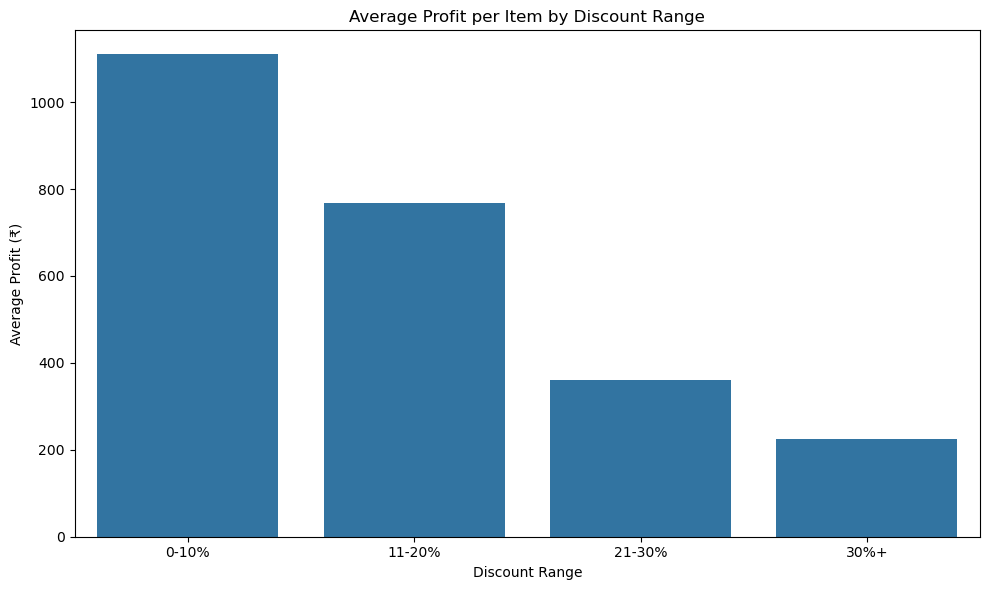

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_analysis,
    x="Discount_Range",
    y="average_profit"
)

plt.title("Average Profit per Item by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit (₹)")
plt.tight_layout()
plt.show()

In [16]:
order_sales["Month"] = order_sales["Order_Date"].dt.to_period("M").astype(str)

In [17]:
monthly_revenue = (
    order_sales
    .groupby("Month")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        units_sold=("Quantity", "sum")
    )
    .reset_index()
)

monthly_revenue.head()

,Month,total_revenue,total_profit,units_sold
0,2024-01,27986376.65,7246616.65,10311
1,2024-02,27532048.50,6864708.50,9604
2,2024-03,27379465.98,6950715.98,9873
3,2024-04,27629834.14,7147054.14,9984
4,2024-05,30141183.28,7761283.28,10403


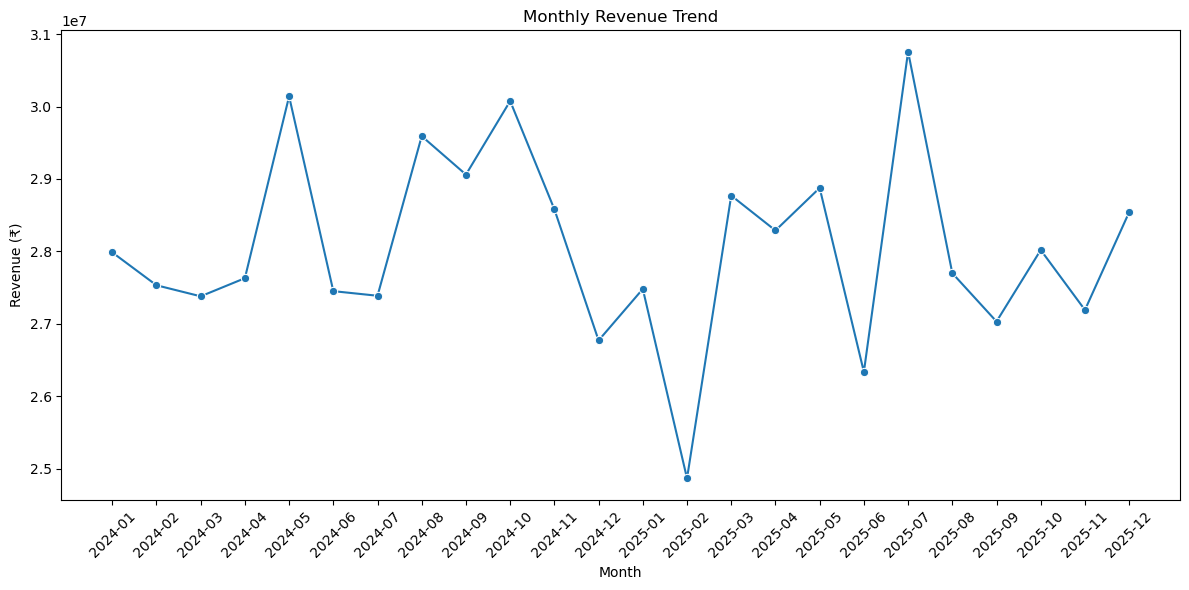

In [18]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

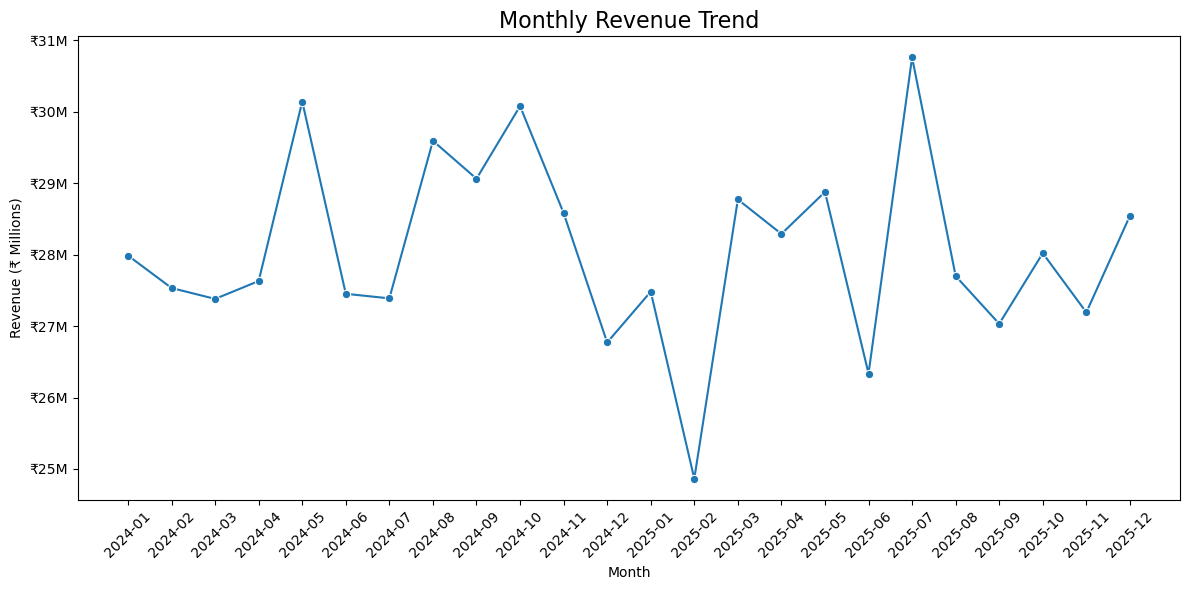

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Millions)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()

In [20]:
category_revenue = (
    order_sales
    .groupby("Category")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        units_sold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

category_revenue

,Category,total_revenue,total_profit,units_sold
3,Electronics,3.038048e+08,76696286.76,30384
7,Sports,1.022450e+08,24535431.26,30299
6,Home & Kitchen,8.188930e+07,22910935.44,30395
4,Fashion,6.555364e+07,16558949.40,30689
0,Accessories,5.683752e+07,15371513.74,30688
1,Beauty,3.295949e+07,8420639.54,30421
5,Grocery,1.606133e+07,4064934.83,30532
2,Books,1.409482e+07,3714498.54,30695


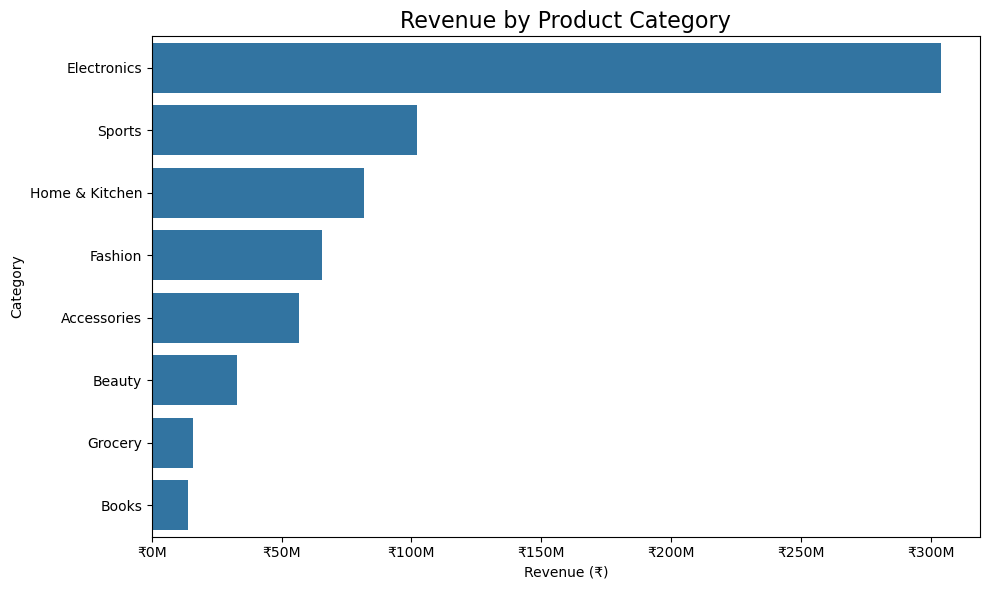

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="total_revenue",
    y="Category"
)

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()

In [22]:
category_profit = (
    order_sales
    .groupby("Category")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("total_profit", ascending=False)
)

category_profit

,Category,total_revenue,total_profit
3,Electronics,3.038048e+08,76696286.76
7,Sports,1.022450e+08,24535431.26
6,Home & Kitchen,8.188930e+07,22910935.44
4,Fashion,6.555364e+07,16558949.40
0,Accessories,5.683752e+07,15371513.74
1,Beauty,3.295949e+07,8420639.54
5,Grocery,1.606133e+07,4064934.83
2,Books,1.409482e+07,3714498.54


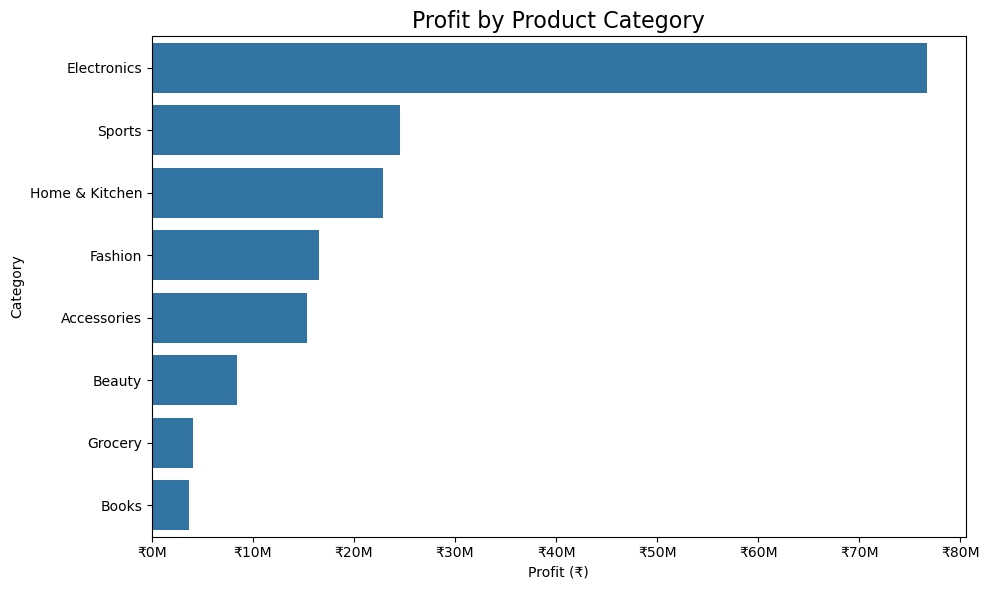

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profit,
    x="total_profit",
    y="Category"
)

plt.title("Profit by Product Category", fontsize=16)
plt.xlabel("Profit (₹)")
plt.ylabel("Category")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()

In [24]:
top_products_revenue = (
    order_sales
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        units_sold=("Quantity", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_products_revenue

,Product_ID,Product_Name,Category,total_revenue,units_sold,total_profit
17,PROD0018,Mechanical Keyboard Lite,Electronics,26012311.26,526,4341111.26
25,PROD0026,Bluetooth Speaker Plus,Electronics,24686487.00,487,4461377.00
26,PROD0027,Neckband Plus,Electronics,21232574.10,494,2944694.10
56,PROD0057,Power Bank Max,Electronics,18936047.38,463,3212567.38
52,PROD0053,Wireless Mouse Max,Electronics,18642951.84,509,6671271.84
44,PROD0045,Power Bank Pro,Electronics,17894081.28,550,4996581.28
59,PROD0060,Phone Case Max,Electronics,16912962.50,502,4428222.50
40,PROD0041,Wireless Mouse Pro,Electronics,13553130.36,474,3120390.36
6,PROD0007,Laptop Stand,Electronics,11542027.20,474,4237687.20
31,PROD0032,Webcam Plus,Electronics,11309717.25,478,3556557.25


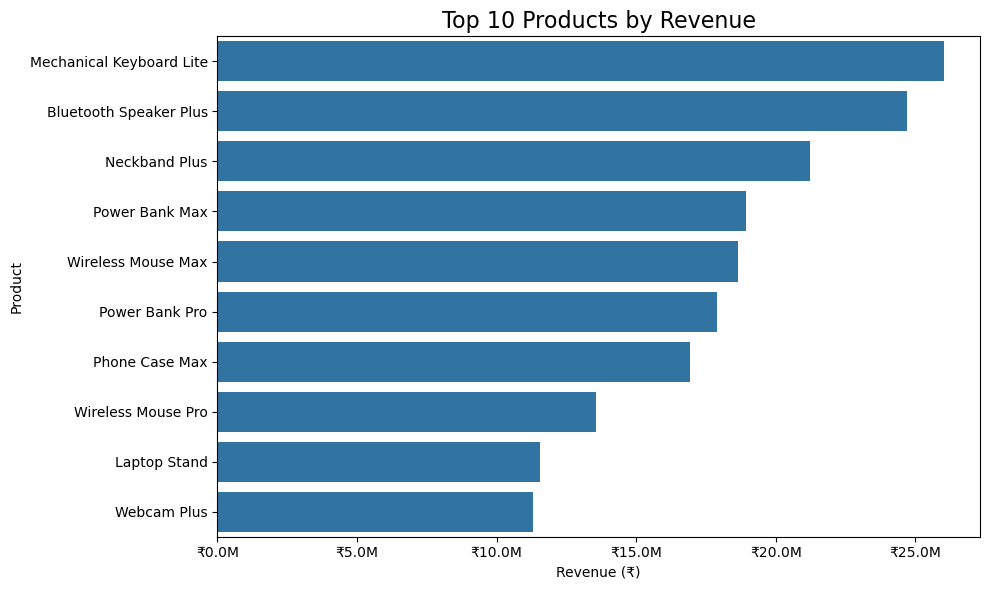

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products_revenue,
    x="total_revenue",
    y="Product_Name"
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.1f}M")
)

plt.tight_layout()
plt.show()

In [26]:
top_products_profit = (
    order_sales
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_cost=("Total_Cost", "sum"),
        total_profit=("Profit", "sum"),
        units_sold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("total_profit", ascending=False)
    .head(10)
)

top_products_profit

,Product_ID,Product_Name,Category,total_revenue,total_cost,total_profit,units_sold
52,PROD0053,Wireless Mouse Max,Electronics,18642951.84,11971680.0,6671271.84,509
44,PROD0045,Power Bank Pro,Electronics,17894081.28,12897500.0,4996581.28,550
25,PROD0026,Bluetooth Speaker Plus,Electronics,24686487.00,20225110.0,4461377.00,487
59,PROD0060,Phone Case Max,Electronics,16912962.50,12484740.0,4428222.50,502
17,PROD0018,Mechanical Keyboard Lite,Electronics,26012311.26,21671200.0,4341111.26,526
6,PROD0007,Laptop Stand,Electronics,11542027.20,7304340.0,4237687.20,474
58,PROD0059,USB-C Cable Max,Electronics,9983287.23,6262620.0,3720667.23,481
31,PROD0032,Webcam Plus,Electronics,11309717.25,7753160.0,3556557.25,478
38,PROD0039,Neckband Pro,Electronics,7878008.00,4635000.0,3243008.00,450
56,PROD0057,Power Bank Max,Electronics,18936047.38,15723480.0,3212567.38,463


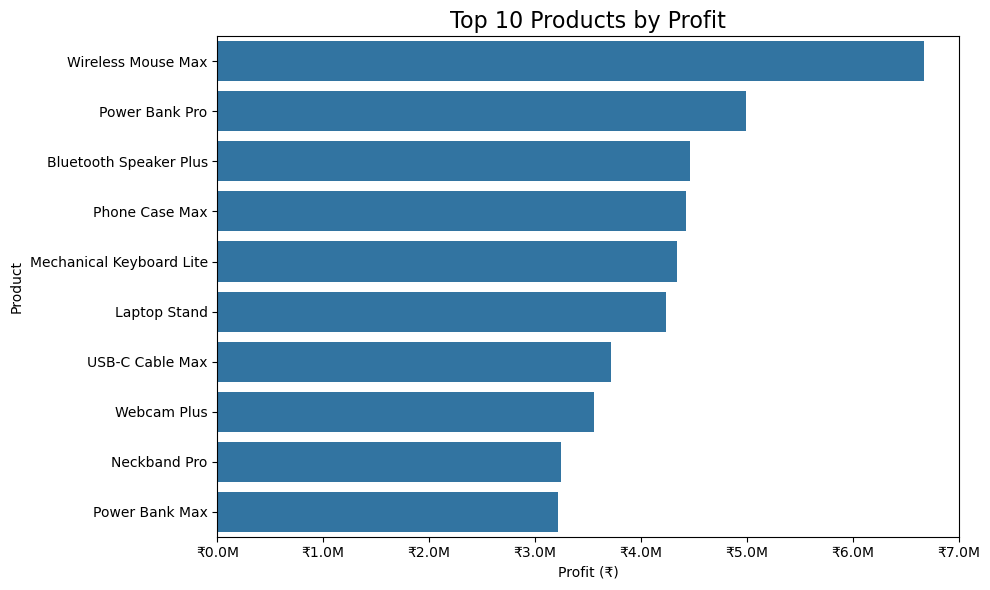

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products_profit,
    x="total_profit",
    y="Product_Name"
)

plt.title("Top 10 Products by Profit", fontsize=16)
plt.xlabel("Profit (₹)")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.1f}M")
)

plt.tight_layout()
plt.show()

In [28]:
product_profitability = (
    order_sales
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_cost=("Total_Cost", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)

product_profitability["profit_margin_percent"] = (
    product_profitability["total_profit"]
    / product_profitability["total_revenue"]
    * 100
)

product_profitability = product_profitability.sort_values(
    "profit_margin_percent",
    ascending=False
)

product_profitability.head(10)

,Product_ID,Product_Name,Category,total_revenue,total_cost,total_profit,profit_margin_percent
167,PROD0168,Hoodie Classic,Fashion,119346.02,66900.0,52446.02,43.944507
185,PROD0186,Saree Ultra,Fashion,155573.60,87300.0,68273.60,43.885081
85,PROD0086,Table Lamp Plus,Home & Kitchen,1264310.36,711450.0,552860.36,43.728216
410,PROD0411,Dry Fruits Max,Grocery,577052.44,324720.0,252332.44,43.727818
449,PROD0450,Belt Lite,Accessories,95982.18,54340.0,41642.18,43.385324
203,PROD0204,Moisturizer Plus,Beauty,221090.72,125520.0,95570.72,43.226925
102,PROD0103,Mixer Grinder Classic,Home & Kitchen,882777.82,501760.0,381017.82,43.161236
299,PROD0300,Skipping Rope Premium,Sports,161153.64,92150.0,69003.64,42.818543
462,PROD0463,Analog Watch Pro,Accessories,476865.38,273840.0,203025.38,42.574988
142,PROD0143,Running Shoes Plus,Fashion,797864.30,458640.0,339224.30,42.516541


In [29]:
state_analysis = (
    order_sales
    .groupby("State")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        units_sold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

state_analysis.head(10)

,State,total_revenue,total_profit,units_sold
7,Maharashtra,76764726.99,19802476.99,28046
4,Karnataka,59694423.08,15127973.08,21007
13,Uttar Pradesh,58759950.29,14988220.29,21254
11,Tamil Nadu,55621019.16,14213459.16,19640
6,Madhya Pradesh,53229862.76,13553552.76,19164
1,Delhi,50791803.10,12926483.10,18640
2,Gujarat,50713171.84,13113821.84,18371
12,Telangana,43473039.29,11129619.29,16284
10,Rajasthan,39792660.29,10046980.29,14211
14,West Bengal,38679549.62,9833759.62,14092


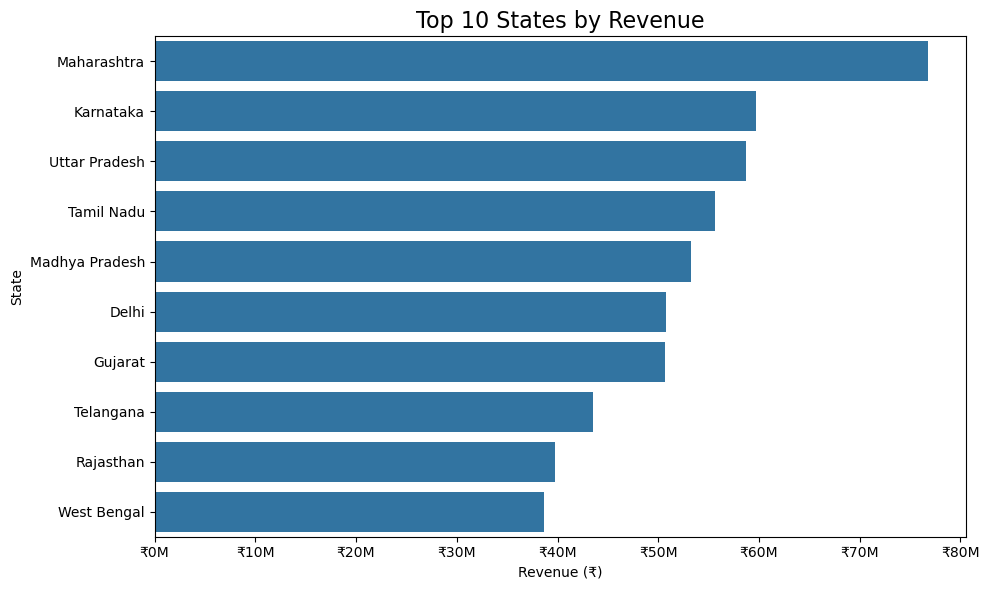

In [30]:
top_states = state_analysis.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x="total_revenue",
    y="State"
)

plt.title("Top 10 States by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("State")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"₹{x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()

In [31]:
state_profitability = (
    order_sales
    .groupby("State")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)

state_profitability["profit_margin_percent"] = (
    state_profitability["total_profit"]
    / state_profitability["total_revenue"]
    * 100
)

state_profitability = state_profitability.sort_values(
    "profit_margin_percent",
    ascending=False
)

state_profitability.head(10)

,State,total_revenue,total_profit,profit_margin_percent
3,Haryana,30254272.59,7832122.59,25.887658
2,Gujarat,50713171.84,13113821.84,25.858808
7,Maharashtra,76764726.99,19802476.99,25.796323
9,Punjab,25653290.91,6613380.91,25.779854
0,Bihar,26156736.85,6715866.85,25.675477
5,Kerala,37389617.47,9591917.47,25.653960
8,Odisha,26471845.27,6783555.27,25.625547
12,Telangana,43473039.29,11129619.29,25.601199
11,Tamil Nadu,55621019.16,14213459.16,25.554115
13,Uttar Pradesh,58759950.29,14988220.29,25.507544


In [32]:
shipping_analysis = shipping.copy()

shipping_analysis["Delivery_Days"] = (
    shipping_analysis["Delivery_Date"]
    - shipping_analysis["Shipping_Date"]
).dt.days

shipping_analysis.head()

,Order_ID,Shipping_Date,Expected_Delivery_Date,Delivery_Date,Delivery_Status,Shipping_Cost,Delivery_Days
0,ORD000001,2025-01-14,2025-01-18,2025-01-18,On Time,161.40,4
1,ORD000002,2024-06-22,2024-06-27,2024-06-27,On Time,139.08,5
2,ORD000003,2025-05-16,2025-05-20,2025-05-20,On Time,87.03,4
3,ORD000004,2024-10-08,2024-10-14,2024-10-14,On Time,47.06,6
4,ORD000005,2025-12-22,2025-12-26,2025-12-26,On Time,175.36,4


In [33]:
print("Average delivery days:",
      shipping_analysis["Delivery_Days"].mean())

print("Minimum delivery days:",
      shipping_analysis["Delivery_Days"].min())

print("Maximum delivery days:",
      shipping_analysis["Delivery_Days"].max())

Average delivery days: 3.786037188227556
Minimum delivery days: 0
Maximum delivery days: 11


In [34]:
delivery_status = (
    shipping_analysis
    .groupby("Delivery_Status")
    .agg(
        total_orders=("Order_ID", "count"),
        average_delivery_days=("Delivery_Days", "mean")
    )
    .reset_index()
)

delivery_status

,Delivery_Status,total_orders,average_delivery_days
0,Late,17343,5.547829
1,On Time,78440,3.396507


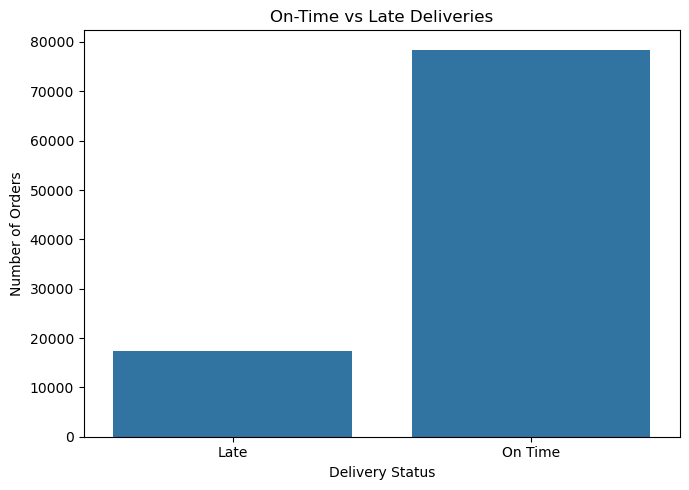

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=delivery_status,
    x="Delivery_Status",
    y="total_orders"
)

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [36]:
shipping_with_method = shipping_analysis.merge(
    orders[["Order_ID", "Shipping_Method"]],
    on="Order_ID",
    how="left"
)

shipping_method = (
    shipping_with_method
    .groupby("Shipping_Method")
    .agg(
        total_orders=("Order_ID", "count"),
        average_delivery_days=("Delivery_Days", "mean")
    )
    .reset_index()
)

shipping_method["average_delivery_days"] = (
    shipping_method["average_delivery_days"].round(2)
)

shipping_method

,Shipping_Method,total_orders,average_delivery_days
0,Express,28483,2.39
1,Same Day,7771,0.39
2,Standard,59529,4.90


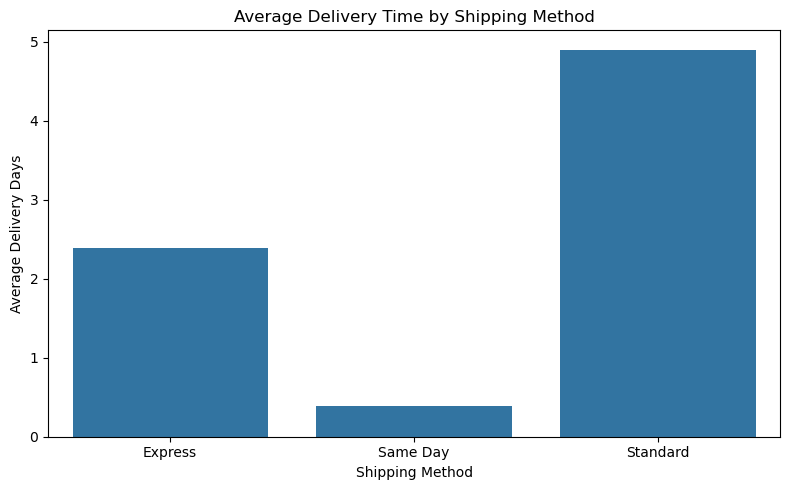

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shipping_method,
    x="Shipping_Method",
    y="average_delivery_days"
)

plt.title("Average Delivery Time by Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Average Delivery Days")

plt.tight_layout()
plt.show()

In [38]:
late_delivery_method = (
    shipping_with_method
    .groupby("Shipping_Method")
    .agg(
        total_orders=("Order_ID", "count"),
        late_orders=("Delivery_Status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

late_delivery_method["late_delivery_percent"] = (
    late_delivery_method["late_orders"]
    / late_delivery_method["total_orders"]
    * 100
).round(2)

late_delivery_method = late_delivery_method.sort_values(
    "late_delivery_percent",
    ascending=False
)

late_delivery_method

,Shipping_Method,total_orders,late_orders,late_delivery_percent
1,Same Day,7771,1424,18.32
2,Standard,59529,10831,18.19
0,Express,28483,5088,17.86


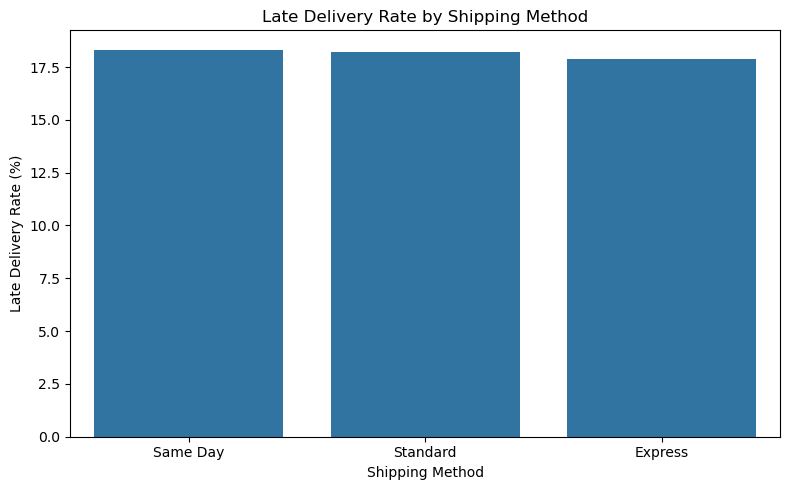

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=late_delivery_method,
    x="Shipping_Method",
    y="late_delivery_percent"
)

plt.title("Late Delivery Rate by Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Late Delivery Rate (%)")

plt.tight_layout()
plt.show()

In [40]:
# Merge shipping data with customer state
shipping_state = shipping_analysis.merge(
    orders[["Order_ID", "Customer_ID"]],
    on="Order_ID",
    how="left"
)

shipping_state = shipping_state.merge(
    customers[["Customer_ID", "State"]],
    on="Customer_ID",
    how="left"
)

# Calculate late delivery rate by state
late_delivery_state = (
    shipping_state
    .groupby("State")
    .agg(
        total_orders=("Order_ID", "count"),
        late_orders=("Delivery_Status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

late_delivery_state["late_delivery_percent"] = (
    late_delivery_state["late_orders"]
    / late_delivery_state["total_orders"]
    * 100
)

late_delivery_state = late_delivery_state.sort_values(
    "late_delivery_percent",
    ascending=False
)

late_delivery_state.head(10)

,State,total_orders,late_orders,late_delivery_percent
9,Punjab,3751,718,19.141562
5,Kerala,5426,1015,18.706229
3,Haryana,4565,849,18.598028
11,Tamil Nadu,7741,1432,18.498902
12,Telangana,6379,1178,18.466844
6,Madhya Pradesh,7520,1387,18.444149
0,Bihar,3609,654,18.121363
8,Odisha,3654,660,18.062397
13,Uttar Pradesh,8277,1494,18.050018
2,Gujarat,7171,1291,18.003068


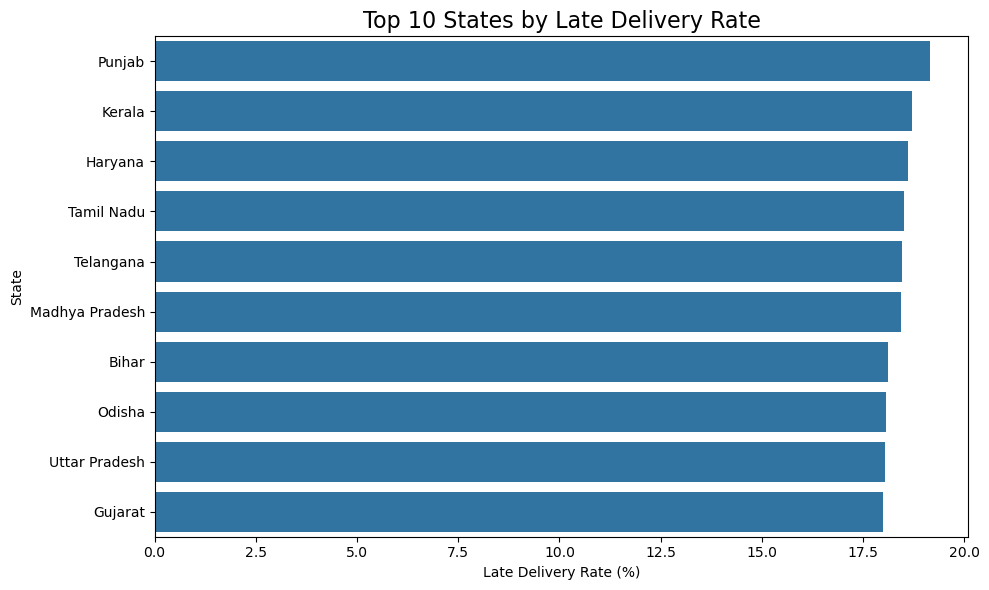

In [41]:
plt.figure(figsize=(10, 6))

top_late_states = late_delivery_state.head(10)

sns.barplot(
    data=top_late_states,
    x="late_delivery_percent",
    y="State"
)

plt.title("Top 10 States by Late Delivery Rate", fontsize=16)
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [43]:
# Merge delivery status with returns
delivery_returns = shipping_analysis.merge(
    returns[["Order_ID"]],
    on="Order_ID",
    how="left",
    indicator=True
)

# Mark whether an order was returned
delivery_returns["Returned"] = (
    delivery_returns["_merge"] == "both"
)

# Calculate return rate by delivery status
return_by_delivery = (
    delivery_returns
    .groupby("Delivery_Status")
    .agg(
        total_orders=("Order_ID", "count"),
        returned_orders=("Returned", "sum")
    )
    .reset_index()
)

return_by_delivery["return_rate_percent"] = (
    return_by_delivery["returned_orders"]
    / return_by_delivery["total_orders"]
    * 100
)

return_by_delivery

,Delivery_Status,total_orders,returned_orders,return_rate_percent
0,Late,17343,914,5.270138
1,On Time,78440,4032,5.140235


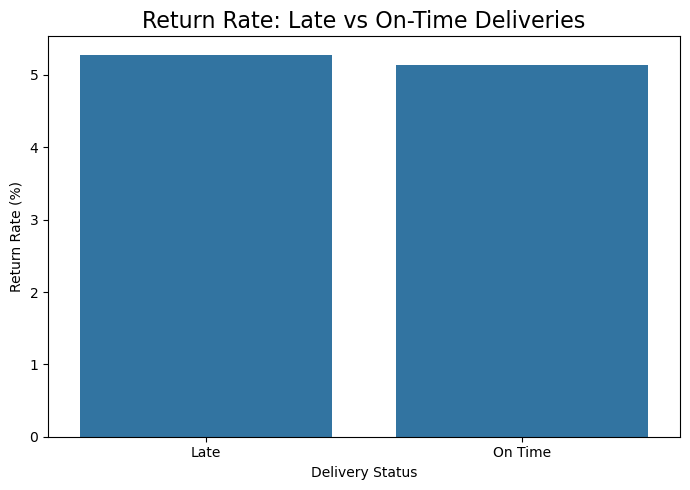

In [44]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=return_by_delivery,
    x="Delivery_Status",
    y="return_rate_percent"
)

plt.title("Return Rate: Late vs On-Time Deliveries", fontsize=16)
plt.xlabel("Delivery Status")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

In [45]:
return_reason_analysis = (
    returns
    .groupby("Return_Reason")
    .agg(
        total_returns=("Return_ID", "count"),
        total_refund_amount=("Refund_Amount", "sum")
    )
    .reset_index()
)

return_reason_analysis["return_percentage"] = (
    return_reason_analysis["total_returns"]
    / return_reason_analysis["total_returns"].sum()
    * 100
)

return_reason_analysis = return_reason_analysis.sort_values(
    "total_returns",
    ascending=False
)

return_reason_analysis

,Return_Reason,total_returns,total_refund_amount,return_percentage
5,Size/Fit Issue,879,5291252.57,17.771937
4,Product Not as Expected,845,5178091.67,17.084513
1,Damaged,791,4907775.96,15.992721
3,Poor Quality,764,4538485.85,15.446826
0,Changed Mind,603,3712802.55,12.191670
6,Wrong Product,583,3786900.93,11.787303
2,Late Delivery,481,2929304.92,9.725030


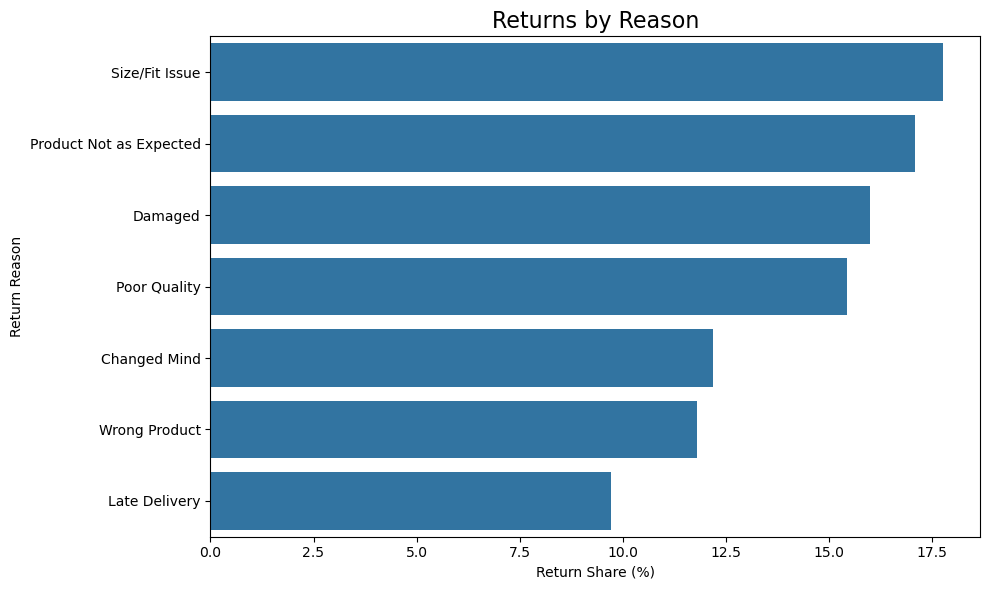

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=return_reason_analysis,
    x="return_percentage",
    y="Return_Reason"
)

plt.title("Returns by Reason", fontsize=16)
plt.xlabel("Return Share (%)")
plt.ylabel("Return Reason")

plt.tight_layout()
plt.show()

In [47]:
# Create category-level order data
category_orders = (
    order_sales[
        ["Order_ID", "Category"]
    ]
    .drop_duplicates()
)

# Mark whether each order was returned
returned_order_ids = set(returns["Order_ID"])

category_orders["Returned"] = category_orders["Order_ID"].isin(
    returned_order_ids
)

# Calculate return analysis by category
category_return_analysis = (
    category_orders
    .groupby("Category")
    .agg(
        total_orders=("Order_ID", "nunique"),
        returned_orders=("Returned", "sum")
    )
    .reset_index()
)

category_return_analysis["return_rate_percent"] = (
    category_return_analysis["returned_orders"]
    / category_return_analysis["total_orders"]
    * 100
)

category_return_analysis = category_return_analysis.sort_values(
    "return_rate_percent",
    ascending=False
)

category_return_analysis

,Category,total_orders,returned_orders,return_rate_percent
1,Beauty,20061,1011,5.039629
7,Sports,19864,982,4.943617
6,Home & Kitchen,20066,991,4.938702
0,Accessories,20026,985,4.918606
5,Grocery,20014,979,4.891576
4,Fashion,20092,981,4.882540
3,Electronics,19954,970,4.861181
2,Books,20163,979,4.855428


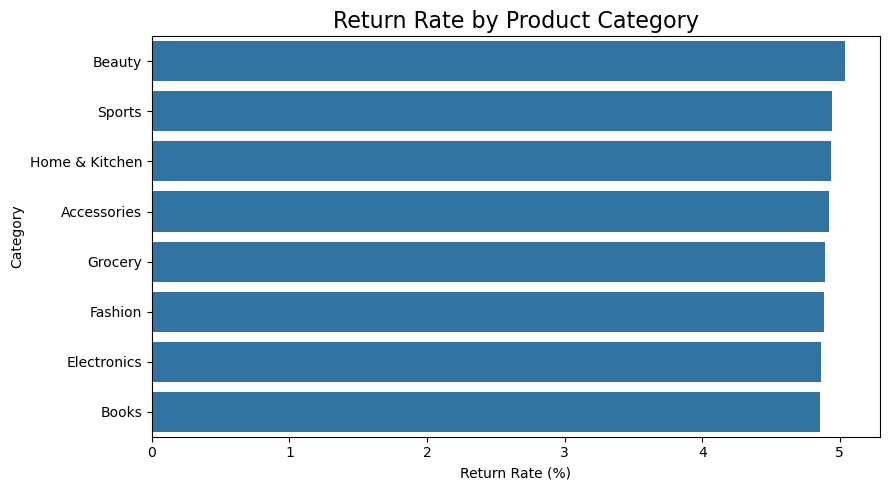

In [48]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_return_analysis,
    x="return_rate_percent",
    y="Category"
)

plt.title("Return Rate by Product Category", fontsize=16)
plt.xlabel("Return Rate (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [49]:
# Get returned orders
returned_orders = returns[["Order_ID"]].drop_duplicates()

# Connect returned orders with product information
product_returns = order_sales.merge(
    returned_orders,
    on="Order_ID",
    how="inner"
)

# Analyze returned orders by product
product_return_analysis = (
    product_returns
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        returned_orders=("Order_ID", "nunique"),
        returned_quantity=("Quantity", "sum")
    )
    .reset_index()
)

product_return_analysis = product_return_analysis.sort_values(
    "returned_orders",
    ascending=False
)

product_return_analysis.head(10)

,Product_ID,Product_Name,Category,returned_orders,returned_quantity
68,PROD0069,Storage Box,Home & Kitchen,29,45
135,PROD0136,Hoodie Lite,Fashion,29,41
137,PROD0138,Saree Lite,Fashion,27,36
227,PROD0228,Moisturizer Classic,Beauty,27,35
348,PROD0349,Personal Finance Max,Books,26,35
200,PROD0201,Hair Oil Lite,Beauty,26,34
44,PROD0045,Power Bank Pro,Electronics,25,33
398,PROD0399,Cooking Oil Pro,Grocery,25,39
52,PROD0053,Wireless Mouse Max,Electronics,25,34
102,PROD0103,Mixer Grinder Classic,Home & Kitchen,25,36


In [50]:
# Total unique orders per product
product_orders = (
    order_sales
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        total_orders=("Order_ID", "nunique")
    )
    .reset_index()
)

# Combine with returned orders
product_return_rate = product_orders.merge(
    product_return_analysis[
        ["Product_ID", "returned_orders"]
    ],
    on="Product_ID",
    how="left"
)

# Products with no returns get 0
product_return_rate["returned_orders"] = (
    product_return_rate["returned_orders"]
    .fillna(0)
)

product_return_rate["return_rate_percent"] = (
    product_return_rate["returned_orders"]
    / product_return_rate["total_orders"]
    * 100
)

# Avoid very small samples:
# only include products with at least 100 orders
product_return_rate = product_return_rate[
    product_return_rate["total_orders"] >= 100
]

product_return_rate = product_return_rate.sort_values(
    "return_rate_percent",
    ascending=False
)

product_return_rate.head(10)

,Product_ID,Product_Name,Category,total_orders,returned_orders,return_rate_percent
68,PROD0069,Storage Box,Home & Kitchen,322,29,9.006211
135,PROD0136,Hoodie Lite,Fashion,353,29,8.215297
200,PROD0201,Hair Oil Lite,Beauty,319,26,8.150470
227,PROD0228,Moisturizer Classic,Beauty,336,27,8.035714
102,PROD0103,Mixer Grinder Classic,Home & Kitchen,320,25,7.812500
270,PROD0271,Badminton Racket Plus,Sports,326,25,7.668712
398,PROD0399,Cooking Oil Pro,Grocery,334,25,7.485030
137,PROD0138,Saree Lite,Fashion,364,27,7.417582
16,PROD0017,Wireless Mouse Lite,Electronics,326,24,7.361963
348,PROD0349,Personal Finance Max,Books,354,26,7.344633


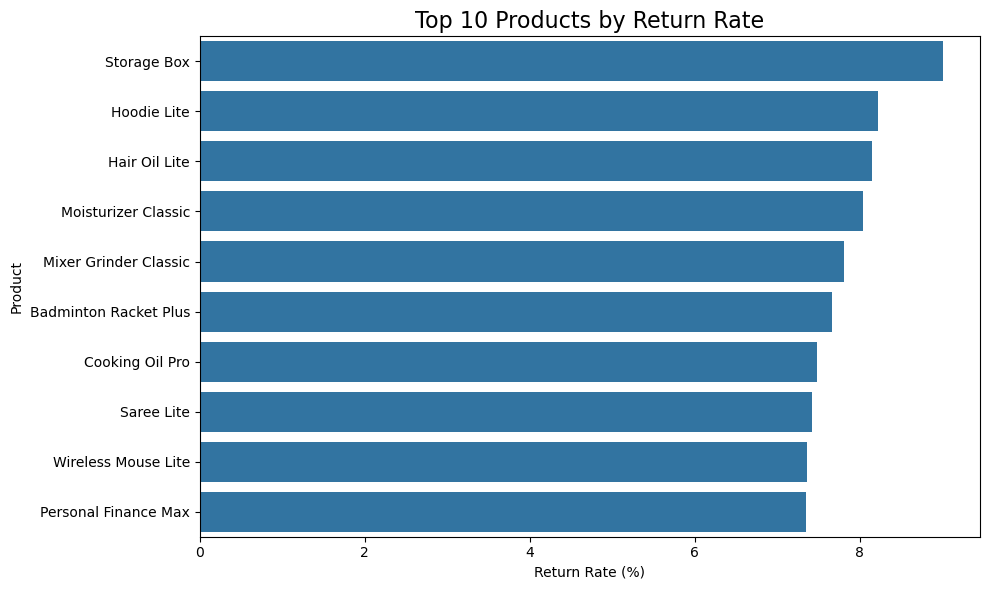

In [51]:
top_return_products = product_return_rate.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_return_products,
    x="return_rate_percent",
    y="Product_Name"
)

plt.title("Top 10 Products by Return Rate", fontsize=16)
plt.xlabel("Return Rate (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [52]:
customer_analysis = (
    order_sales
    .groupby(["Customer_ID", "Customer_Name"])
    .agg(
        total_orders=("Order_ID", "nunique"),
        total_quantity=("Quantity", "sum"),
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)

customer_analysis["AOV"] = (
    customer_analysis["total_revenue"]
    / customer_analysis["total_orders"]
)

customer_analysis.head()

,Customer_ID,Customer_Name,total_orders,total_quantity,total_revenue,total_profit,AOV
0,CUST00001,Arjun Agarwal,3,14,22329.85,4109.85,7443.283333
1,CUST00002,Neha Malhotra,6,13,41829.52,14179.52,6971.586667
2,CUST00003,Akash Singh,2,3,3408.79,878.79,1704.395000
3,CUST00004,Aditya Joshi,10,18,50659.00,11669.00,5065.900000
4,CUST00005,Aanya Agarwal,5,11,20284.63,7504.63,4056.926000


In [53]:
top_customers_revenue = (
    customer_analysis
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_customers_revenue

,Customer_ID,Customer_Name,total_orders,total_quantity,total_revenue,total_profit,AOV
5683,CUST05720,Rahul Patel,6,21,402568.61,59088.61,67094.768333
10310,CUST10371,Aditi Jain,9,27,318373.69,57003.69,35374.854444
19202,CUST19331,Kunal Panchal,7,27,303204.43,92124.43,43314.918571
19399,CUST19530,Sneha Patel,3,13,296035.33,41645.33,98678.443333
7115,CUST07158,Yash Singh,7,20,290468.53,61028.53,41495.504286
16706,CUST16820,Raj Patel,9,32,283549.71,67729.71,31505.523333
11095,CUST11158,Aditya Mishra,10,32,275888.83,61048.83,27588.883000
7864,CUST07909,Yash Verma,8,23,272822.89,89992.89,34102.861250
14643,CUST14741,Diya Gupta,6,22,272167.65,54067.65,45361.275000
7413,CUST07458,Diya Panchal,10,24,270989.25,61589.25,27098.925000


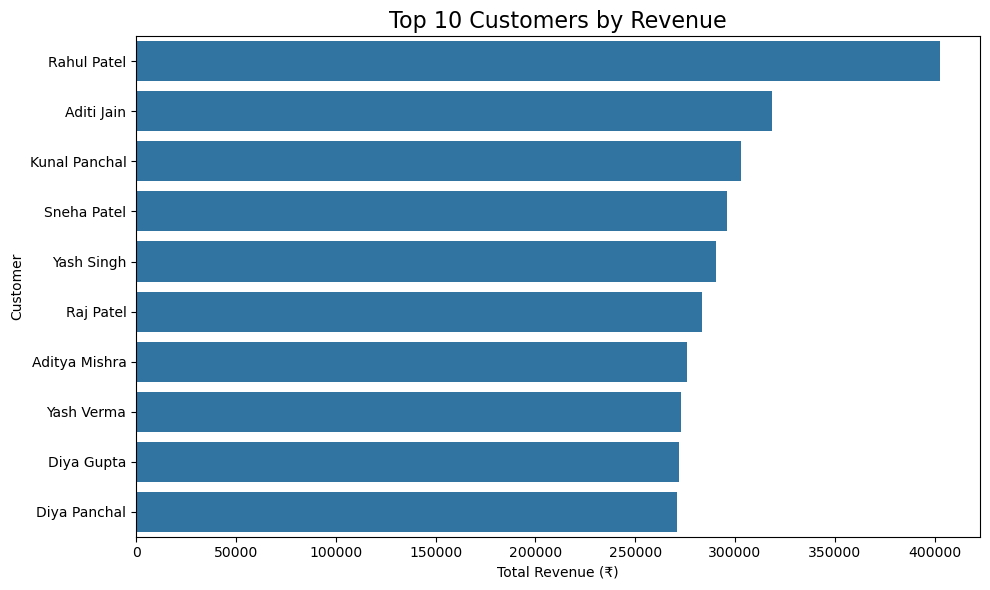

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers_revenue,
    x="total_revenue",
    y="Customer_Name"
)

plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [55]:
top_customers_profit = (
    customer_analysis
    .sort_values("total_profit", ascending=False)
    .head(10)
)

top_customers_profit

,Customer_ID,Customer_Name,total_orders,total_quantity,total_revenue,total_profit,AOV
19202,CUST19331,Kunal Panchal,7,27,303204.43,92124.43,43314.918571
7864,CUST07909,Yash Verma,8,23,272822.89,89992.89,34102.861250
4125,CUST04155,Priya Yadav,2,12,224197.24,73197.24,112098.620000
11362,CUST11429,Pooja Panchal,6,15,252942.50,72432.50,42157.083333
16706,CUST16820,Raj Patel,9,32,283549.71,67729.71,31505.523333
7112,CUST07155,Saurabh Patel,6,22,231372.05,67622.05,38562.008333
1491,CUST01503,Tanya Desai,12,35,194147.42,65897.42,16178.951667
13739,CUST13831,Rohan Gupta,7,17,267635.28,65815.28,38233.611429
9104,CUST09157,Riya Mishra,12,39,270383.89,65333.89,22531.990833
2720,CUST02740,Isha Gupta,5,19,176333.25,65073.25,35266.650000


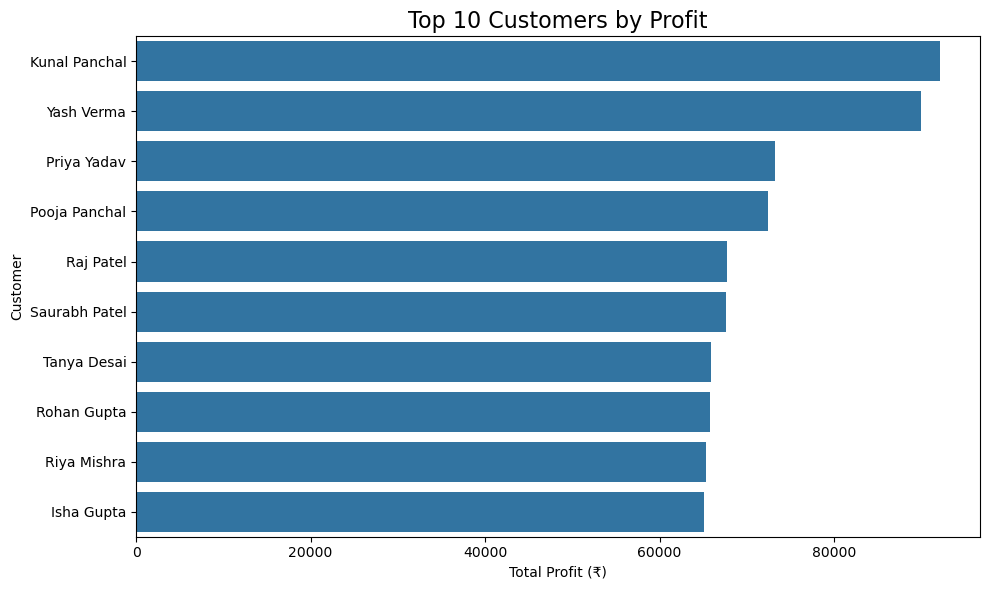

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers_profit,
    x="total_profit",
    y="Customer_Name"
)

plt.title("Top 10 Customers by Profit", fontsize=16)
plt.xlabel("Total Profit (₹)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [57]:
customer_analysis["Customer_Type"] = np.where(
    customer_analysis["total_orders"] == 1,
    "New Customer",
    "Returning Customer"
)

customer_type_summary = (
    customer_analysis
    .groupby("Customer_Type")
    .agg(
        customers=("Customer_ID", "nunique"),
        total_revenue=("total_revenue", "sum"),
        total_profit=("total_profit", "sum")
    )
    .reset_index()
)

customer_type_summary

,Customer_Type,customers,total_revenue,total_profit
0,New Customer,717,4.575350e+06,1.235530e+06
1,Returning Customer,19150,6.688706e+08,1.710377e+08


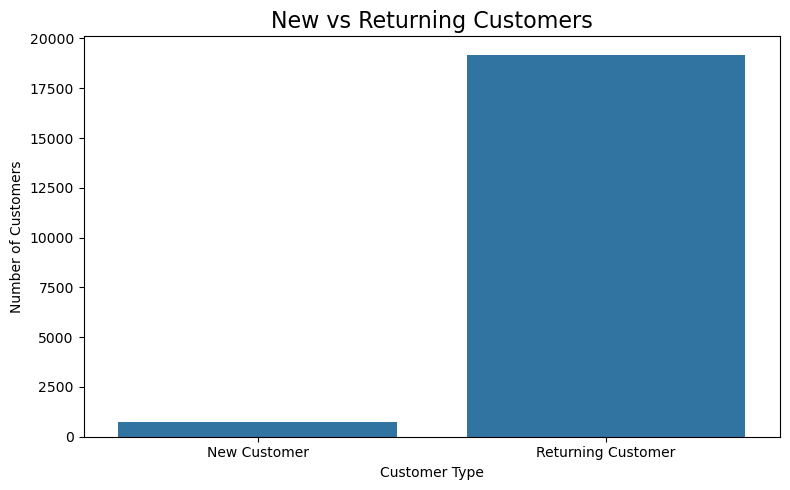

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type_summary,
    x="Customer_Type",
    y="customers"
)

plt.title("New vs Returning Customers", fontsize=16)
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [59]:
total_revenue = customer_type_summary["total_revenue"].sum()

customer_type_summary["revenue_share_percent"] = (
    customer_type_summary["total_revenue"]
    / total_revenue
    * 100
)

customer_type_summary

,Customer_Type,customers,total_revenue,total_profit,revenue_share_percent
0,New Customer,717,4.575350e+06,1.235530e+06,0.679394
1,Returning Customer,19150,6.688706e+08,1.710377e+08,99.320606


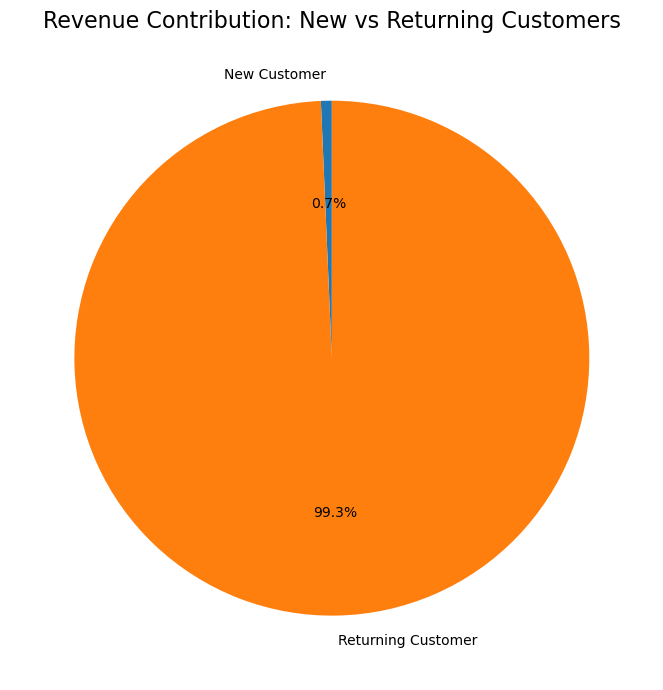

In [60]:
plt.figure(figsize=(7, 7))

plt.pie(
    customer_type_summary["revenue_share_percent"],
    labels=customer_type_summary["Customer_Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution: New vs Returning Customers", fontsize=16)

plt.tight_layout()
plt.show()

In [61]:
# Use completed/returned orders for customer value analysis
rfm_data = order_sales[
    order_sales["Order_Status"].isin(["Delivered", "Returned"])
].copy()

# Create RFM metrics
customer_rfm = (
    rfm_data
    .groupby(["Customer_ID", "Customer_Name"])
    .agg(
        Recency=("Order_Date", lambda x: (pd.Timestamp("2025-12-31") - x.max()).days),
        Frequency=("Order_ID", "nunique"),
        Monetary=("Net_Revenue", "sum")
    )
    .reset_index()
)

customer_rfm.head()

,Customer_ID,Customer_Name,Recency,Frequency,Monetary
0,CUST00001,Arjun Agarwal,89,3,22329.85
1,CUST00002,Neha Malhotra,171,6,41829.52
2,CUST00003,Akash Singh,133,1,558.73
3,CUST00004,Aditya Joshi,76,8,22241.08
4,CUST00005,Aanya Agarwal,34,4,12366.90


In [62]:
# Create RFM scores from 1 to 5

customer_rfm["R_Score"] = pd.qcut(
    customer_rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

customer_rfm["F_Score"] = pd.qcut(
    customer_rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customer_rfm["M_Score"] = pd.qcut(
    customer_rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customer_rfm.head(10)

,Customer_ID,Customer_Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST00001,Arjun Agarwal,89,3,22329.85,3,1,3
1,CUST00002,Neha Malhotra,171,6,41829.52,2,4,4
2,CUST00003,Akash Singh,133,1,558.73,3,1,1
3,CUST00004,Aditya Joshi,76,8,22241.08,4,5,3
4,CUST00005,Aanya Agarwal,34,4,12366.90,4,2,2
5,CUST00006,Varun Mishra,168,7,28870.75,2,4,3
6,CUST00007,Sneha Desai,96,8,17692.89,3,5,3
7,CUST00008,Rahul Jain,657,1,1656.72,1,1,1
8,CUST00009,Harsh Joshi,270,3,7695.16,1,1,1
9,CUST00010,Kavya Shah,123,5,17825.52,3,3,3


In [63]:
def assign_segment(row):
    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "High Value"
    
    elif R >= 4 and F >= 4:
        return "Loyal"
    
    elif R >= 4 and M >= 4:
        return "Potential High Value"
    
    elif R <= 2 and F >= 4:
        return "At Risk"
    
    elif R <= 2 and M >= 4:
        return "At Risk High Spender"
    
    else:
        return "Regular"


customer_rfm["Customer_Segment"] = customer_rfm.apply(
    assign_segment,
    axis=1
)

customer_rfm.head(10)

,Customer_ID,Customer_Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Customer_Segment
0,CUST00001,Arjun Agarwal,89,3,22329.85,3,1,3,Regular
1,CUST00002,Neha Malhotra,171,6,41829.52,2,4,4,At Risk
2,CUST00003,Akash Singh,133,1,558.73,3,1,1,Regular
3,CUST00004,Aditya Joshi,76,8,22241.08,4,5,3,Loyal
4,CUST00005,Aanya Agarwal,34,4,12366.90,4,2,2,Regular
5,CUST00006,Varun Mishra,168,7,28870.75,2,4,3,At Risk
6,CUST00007,Sneha Desai,96,8,17692.89,3,5,3,Regular
7,CUST00008,Rahul Jain,657,1,1656.72,1,1,1,Regular
8,CUST00009,Harsh Joshi,270,3,7695.16,1,1,1,Regular
9,CUST00010,Kavya Shah,123,5,17825.52,3,3,3,Regular


In [64]:
segment_summary = (
    customer_rfm
    .groupby("Customer_Segment")
    .agg(
        customers=("Customer_ID", "nunique"),
        total_revenue=("Monetary", "sum"),
        average_revenue=("Monetary", "mean")
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)

segment_summary

,Customer_Segment,customers,total_revenue,average_revenue
5,Regular,11251,2.194950e+08,19508.930939
2,High Value,2708,1.726453e+08,63753.785742
0,At Risk,1902,8.176892e+07,42991.022581
3,Loyal,1522,2.841176e+07,18667.385072
1,At Risk High Spender,1371,7.804738e+07,56927.334471
4,Potential High Value,1070,5.956969e+07,55672.607776


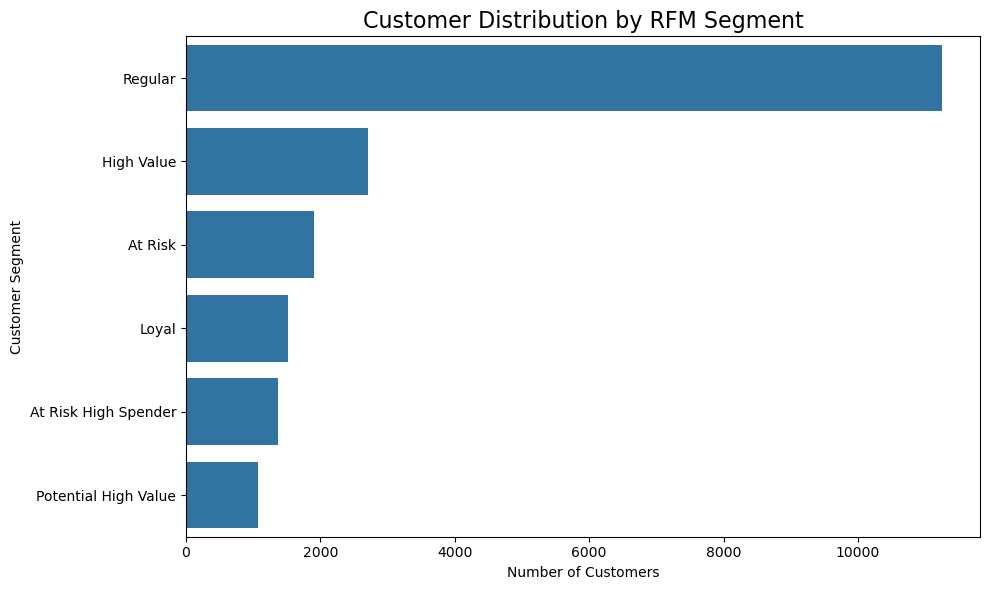

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="customers",
    y="Customer_Segment"
)

plt.title("Customer Distribution by RFM Segment", fontsize=16)
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

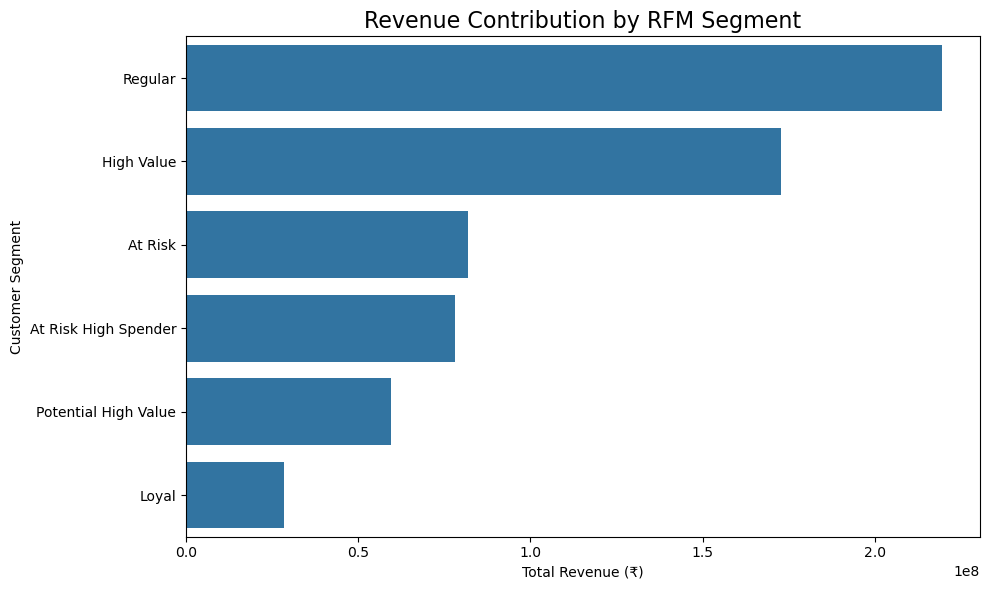

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary.sort_values("total_revenue", ascending=False),
    x="total_revenue",
    y="Customer_Segment"
)

plt.title("Revenue Contribution by RFM Segment", fontsize=16)
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

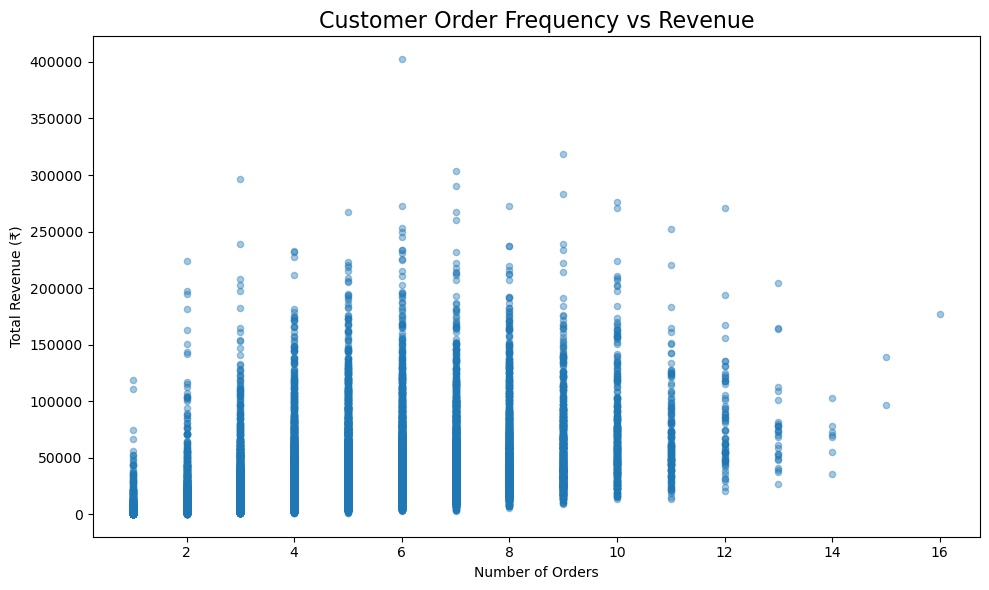

In [67]:
customer_analysis.plot(
    kind="scatter",
    x="total_orders",
    y="total_revenue",
    figsize=(10, 6),
    alpha=0.4
)

plt.title("Customer Order Frequency vs Revenue", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue (₹)")

plt.tight_layout()
plt.show()

In [68]:
discount_analysis = (
    order_sales
    .groupby("Discount_Range", observed=False)
    .agg(
        total_items=("Order_ID", "count"),
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        average_profit=("Profit", "mean")
    )
    .reset_index()
)

discount_analysis

,Discount_Range,total_items,total_revenue,total_profit,average_profit
0,0-10%,121303,4.861905e+08,1.346266e+08,1109.837671
1,11-20%,47373,1.754266e+08,3.641243e+07,768.632533
2,21-30%,3404,1.175084e+07,1.230296e+06,361.426486
3,30%+,17,7.802572e+04,3.825720e+03,225.042353


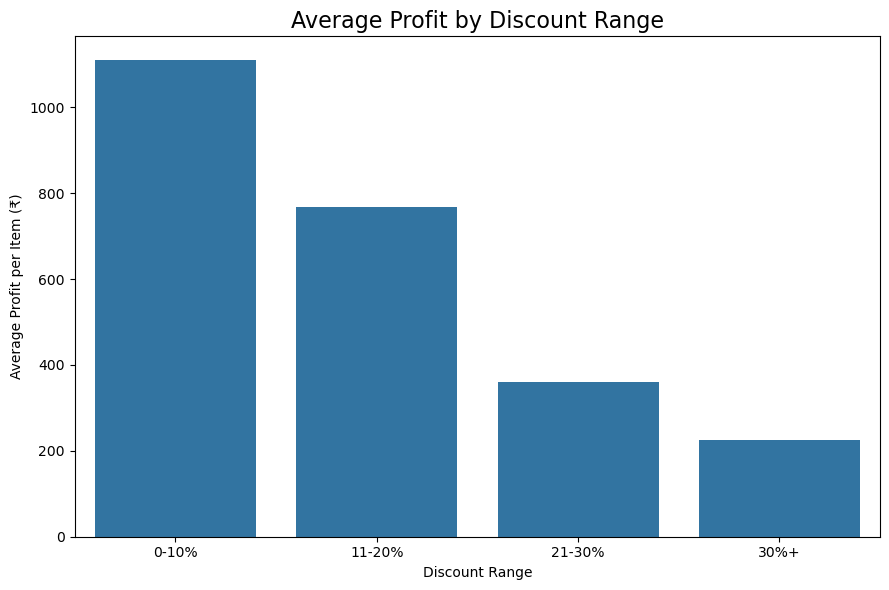

In [69]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=discount_analysis,
    x="Discount_Range",
    y="average_profit"
)

plt.title("Average Profit by Discount Range", fontsize=16)
plt.xlabel("Discount Range")
plt.ylabel("Average Profit per Item (₹)")

plt.tight_layout()
plt.show()

In [70]:
category_performance = (
    order_sales
    .groupby("Category")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)

category_performance

,Category,total_revenue,total_profit
0,Accessories,5.683752e+07,15371513.74
1,Beauty,3.295949e+07,8420639.54
2,Books,1.409482e+07,3714498.54
3,Electronics,3.038048e+08,76696286.76
4,Fashion,6.555364e+07,16558949.40
5,Grocery,1.606133e+07,4064934.83
6,Home & Kitchen,8.188930e+07,22910935.44
7,Sports,1.022450e+08,24535431.26


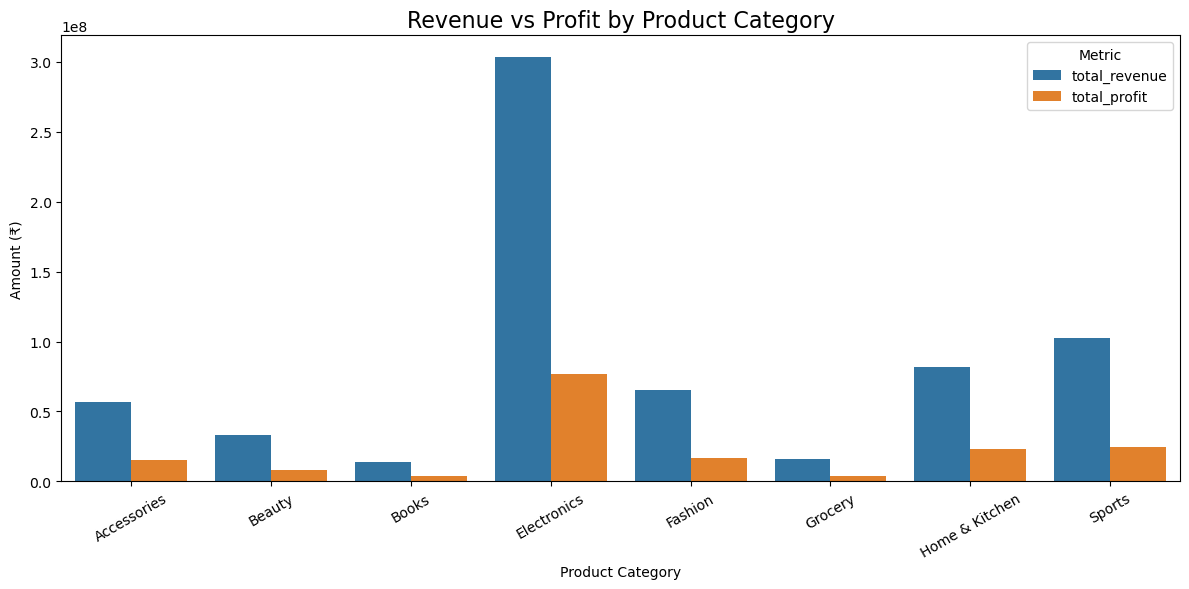

In [71]:
category_performance_melted = category_performance.melt(
    id_vars="Category",
    value_vars=["total_revenue", "total_profit"],
    var_name="Metric",
    value_name="Amount"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_performance_melted,
    x="Category",
    y="Amount",
    hue="Metric"
)

plt.title("Revenue vs Profit by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [72]:
category_performance["profit_margin_percent"] = (
    category_performance["total_profit"]
    / category_performance["total_revenue"]
    * 100
)

category_performance = category_performance.sort_values(
    "profit_margin_percent",
    ascending=False
)

category_performance

,Category,total_revenue,total_profit,profit_margin_percent
6,Home & Kitchen,8.188930e+07,22910935.44,27.977937
0,Accessories,5.683752e+07,15371513.74,27.044658
2,Books,1.409482e+07,3714498.54,26.353646
1,Beauty,3.295949e+07,8420639.54,25.548453
5,Grocery,1.606133e+07,4064934.83,25.308823
4,Fashion,6.555364e+07,16558949.40,25.260153
3,Electronics,3.038048e+08,76696286.76,25.245248
7,Sports,1.022450e+08,24535431.26,23.996700


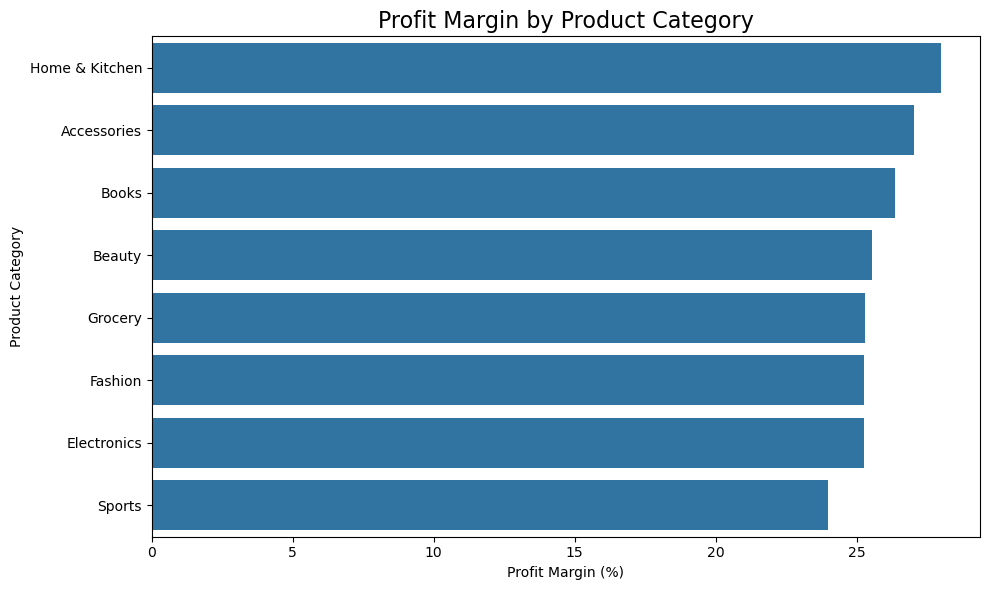

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_performance,
    x="profit_margin_percent",
    y="Category"
)

plt.title("Profit Margin by Product Category", fontsize=16)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [74]:
state_performance = (
    order_sales
    .groupby("State")
    .agg(
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum"),
        total_orders=("Order_ID", "nunique")
    )
    .reset_index()
)

state_performance["profit_margin_percent"] = (
    state_performance["total_profit"]
    / state_performance["total_revenue"]
    * 100
)

state_performance = state_performance.sort_values(
    "total_revenue",
    ascending=False
)

state_performance.head(10)

,State,total_revenue,total_profit,total_orders,profit_margin_percent
7,Maharashtra,76764726.99,19802476.99,11580,25.796323
4,Karnataka,59694423.08,15127973.08,8625,25.342356
13,Uttar Pradesh,58759950.29,14988220.29,8612,25.507544
11,Tamil Nadu,55621019.16,14213459.16,8044,25.554115
6,Madhya Pradesh,53229862.76,13553552.76,7855,25.462310
1,Delhi,50791803.10,12926483.10,7567,25.449939
2,Gujarat,50713171.84,13113821.84,7482,25.858808
12,Telangana,43473039.29,11129619.29,6677,25.601199
10,Rajasthan,39792660.29,10046980.29,5815,25.248325
14,West Bengal,38679549.62,9833759.62,5811,25.423666


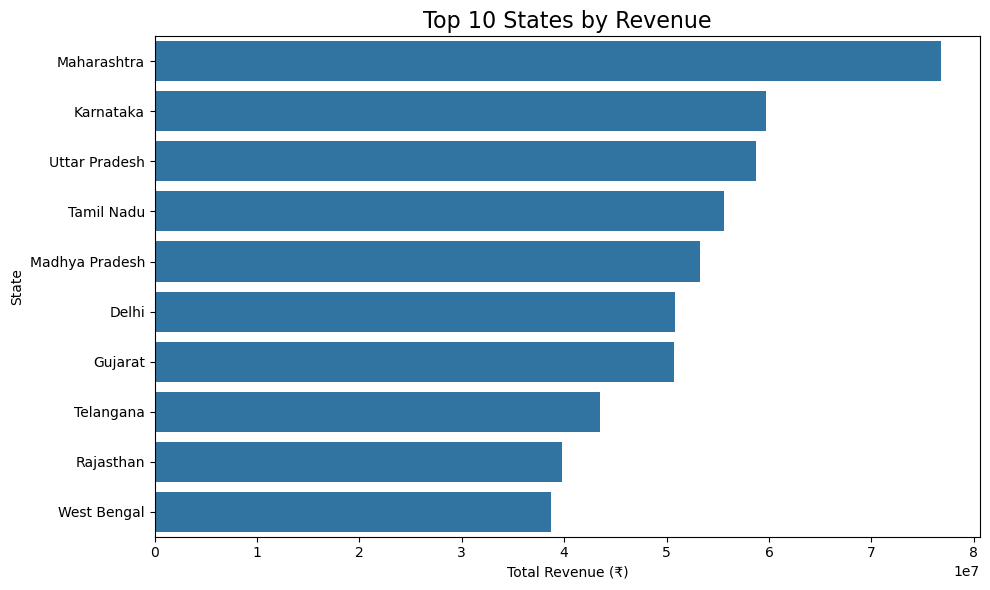

In [75]:
top_states = state_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x="total_revenue",
    y="State"
)

plt.title("Top 10 States by Revenue", fontsize=16)
plt.xlabel("Total Revenue (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [76]:
# Connect shipping with customer/state information
state_shipping = shipping.merge(
    orders[["Order_ID", "Customer_ID"]],
    on="Order_ID",
    how="left"
)

state_shipping = state_shipping.merge(
    customers[["Customer_ID", "State"]],
    on="Customer_ID",
    how="left"
)

# Calculate delivery time
state_shipping["Delivery_Days"] = (
    state_shipping["Delivery_Date"]
    - state_shipping["Shipping_Date"]
).dt.days

# State-level delivery performance
state_delivery_performance = (
    state_shipping
    .groupby("State")
    .agg(
        total_orders=("Order_ID", "nunique"),
        late_orders=("Delivery_Status", lambda x: (x == "Late").sum()),
        average_delivery_days=("Delivery_Days", "mean")
    )
    .reset_index()
)

state_delivery_performance["late_rate_percent"] = (
    state_delivery_performance["late_orders"]
    / state_delivery_performance["total_orders"]
    * 100
)

state_delivery_performance = state_delivery_performance.sort_values(
    "late_rate_percent",
    ascending=False
)

state_delivery_performance.head(10)

,State,total_orders,late_orders,average_delivery_days,late_rate_percent
9,Punjab,3751,718,3.804585,19.141562
5,Kerala,5426,1015,3.783266,18.706229
3,Haryana,4565,849,3.815115,18.598028
11,Tamil Nadu,7741,1432,3.819532,18.498902
12,Telangana,6379,1178,3.802477,18.466844
6,Madhya Pradesh,7520,1387,3.797739,18.444149
0,Bihar,3609,654,3.782488,18.121363
8,Odisha,3654,660,3.842091,18.062397
13,Uttar Pradesh,8277,1494,3.791350,18.050018
2,Gujarat,7171,1291,3.755683,18.003068


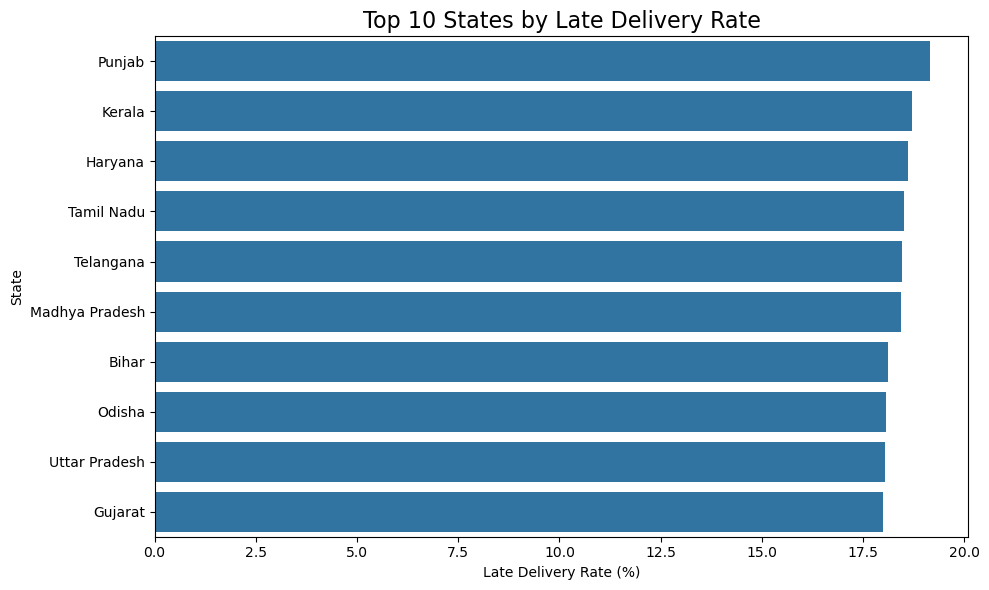

In [77]:
top_late_states = state_delivery_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_late_states,
    x="late_rate_percent",
    y="State"
)

plt.title("Top 10 States by Late Delivery Rate", fontsize=16)
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [78]:
payment_performance = (
    order_sales
    .groupby("Payment_Method")
    .agg(
        total_orders=("Order_ID", "nunique"),
        total_revenue=("Net_Revenue", "sum"),
        total_profit=("Profit", "sum")
    )
    .reset_index()
)

payment_performance["profit_margin_percent"] = (
    payment_performance["total_profit"]
    / payment_performance["total_revenue"]
    * 100
)

payment_performance = payment_performance.sort_values(
    "total_revenue",
    ascending=False
)

payment_performance

,Payment_Method,total_orders,total_revenue,total_profit,profit_margin_percent
4,UPI,33791,2.285498e+08,58623559.70,25.650235
1,Credit Card,20041,1.370102e+08,35131343.27,25.641403
2,Debit Card,17211,1.130470e+08,28859091.35,25.528405
0,Cash on Delivery,13026,8.718137e+07,22008668.16,25.244692
3,Net Banking,9912,6.769946e+07,17315219.47,25.576599
5,Wallet,6019,3.995814e+07,10335307.56,25.865339


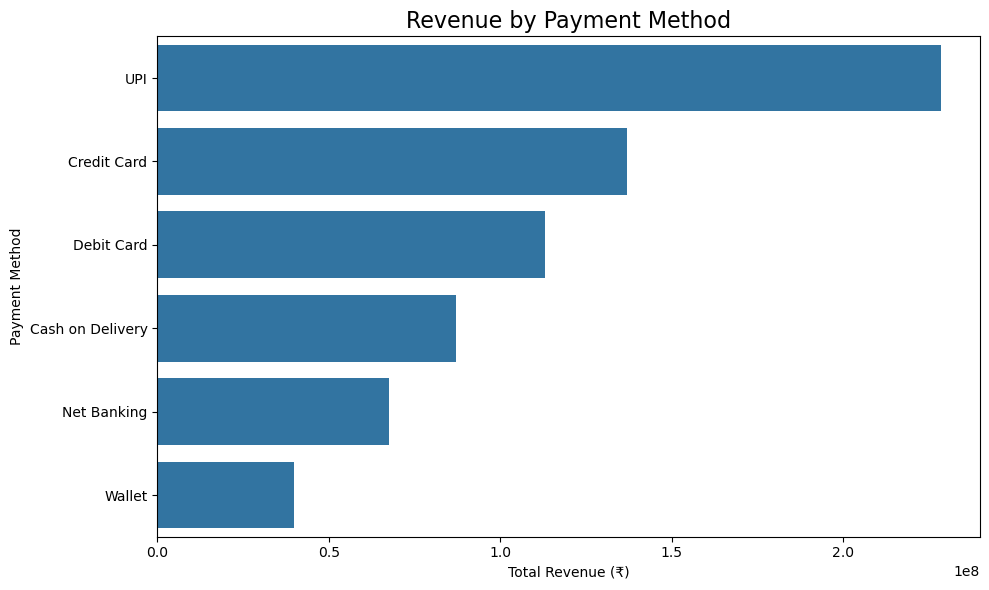

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_performance,
    x="total_revenue",
    y="Payment_Method"
)

plt.title("Revenue by Payment Method", fontsize=16)
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [80]:
# Save important analysis tables for later use

analysis_outputs = {
    "category_performance": category_performance,
    "top_customers_revenue": top_customers_revenue,
    "top_customers_profit": top_customers_profit,
    "segment_summary": segment_summary,
    "state_performance": state_performance,
    "state_delivery_performance": state_delivery_performance,
    "payment_performance": payment_performance,
    "discount_analysis": discount_analysis,
    "product_return_rate": product_return_rate
}

print("Analysis tables prepared:", len(analysis_outputs))

Analysis tables prepared: 9
